In [191]:
import aotools
import numpy
import matplotlib.pyplot as plt
from astropy.io import fits
from PIL import Image, ImageDraw
from tqdm import tqdm, trange, tqdm_notebook
import scipy.signal
import sys,os

In [2]:
data = fits.getdata('tabai5mm.fits')
data[:,:,0:2]=0
array_size=128
padding=2
wavelength=833e-3 #(this is the wavelength data was taken at in microns)
wavelength_m=833e-9
diameter=5e-3 #(pupil diameter in m)
psf_size=array_size*padding
j=0+1j
print(data.shape)

(50, 808, 65)


In [3]:
imfolder='eccentricities'
im1_=Image.open(os.path.join(imfolder,os.listdir(imfolder)[0]))
im1=numpy.asarray(im1_)
w,h =im1.shape
imarray=numpy.zeros((5,w,h))


#make sure you match the 
files=os.listdir(imfolder)

for n in range(5):
    filename=files[n]
    im = Image.open(os.path.join(imfolder,filename))
    image=numpy.asarray(im)
    imarray[n]=image
    

In [4]:
pixel_scale_psf= wavelength_m/(padding*diameter)
pixel_scale_psf_arcmin = (pixel_scale_psf * 180.0 * 60)/numpy.pi
print('The pixel scale of the psf in arcminutes is: %f'%(pixel_scale_psf_arcmin))

The pixel scale of the psf in arcminutes is: 0.286364


In [5]:
n_pixels_image=im1.shape[0]
fov_arcmin=60*2
pixel_scale_image_arcmin=fov_arcmin/n_pixels_image
print('The pixel scale of the image in arcminutes is: %f'%(pixel_scale_image_arcmin))


The pixel scale of the image in arcminutes is: 0.220183


In [6]:
padding_factor=pixel_scale_psf_arcmin/pixel_scale_image_arcmin
print(padding_factor)

1.3005712231123339


In [7]:
frames = data.shape[0]*5
psfs=numpy.load('psf_file.npy')

In [7]:
# check how long it takes to do this for first 100 timepoints
z=aotools.zernikeArray(66,array_size)
z=z[1:] #zernikearray creates an array with piston - our data does not have piston in it, so remove this
#reshape into a 65 x (array_size*array_size) array
zflat=numpy.reshape(z, (z.shape[0],z.shape[1]*z.shape[2]))
psf_size=int(array_size*padding*padding_factor)
padded_pupil = numpy.zeros((psf_size, psf_size), dtype=numpy.complex64)
psfs = numpy.zeros((frames, psf_size, psf_size))
wfs = numpy.zeros((frames, array_size, array_size))
o=0
for n in range(0,50):
    for m in range(0,5):
        
        #print(n,m)
        dat = data[n,m,:]
        #print(dat.shape)


        #convert to radians!
        wf = numpy.dot(dat,zflat)
        wf = numpy.reshape(wf, (z.shape[1],z.shape[2]))
        wf*=aotools.circle(array_size/2, array_size)
        wf*=(2*numpy.pi)/wavelength #convert to radians
        wfs[o]=wf
        complex_phase = numpy.exp(j*wf)
        
        padded_pupil[:array_size, :array_size] = complex_phase
        
        psf = numpy.abs(aotools.ft2(padded_pupil, delta=diameter/array_size))**2
        psfs[o] = psf

        o=o+1




#get the eye data
#calc all psfs
#potentially save array of psfs as a .npy?

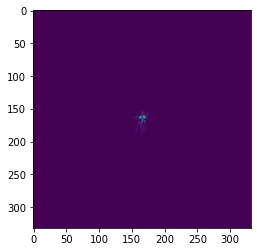

In [8]:
plt.imshow(psfs[0])

In [9]:
numpy.save('psf_file',psfs)

In [10]:
eedata=[]

for n in range(len(psfs)):
    e=aotools.encircled_energy(psfs[n], fraction=0.5, center=None, eeDiameter=True)
    eedata.append(e)

In [11]:
print(eedata)

[13.520361990950226, 13.770739064856713, 13.019607843137255, 13.26998491704374, 12.76923076923077, 23.535444947209655, 23.78582202111614, 23.78582202111614, 23.285067873303166, 22.53393665158371, 32.29864253393665, 32.29864253393665, 32.29864253393665, 30.79638009049774, 31.547511312217196, 37.80693815987934, 37.30618401206637, 37.30618401206637, 39.30920060331825, 37.55656108597285, 20.28054298642534, 20.28054298642534, 20.78129713423831, 20.530920060331823, 20.030165912518854, 19.279034690799396, 16.524886877828052, 18.277526395173453, 16.77526395173454, 18.02714932126697, 38.55806938159879, 38.808446455505276, 39.05882352941177, 38.808446455505276, 39.55957767722474, 40.81146304675716, 41.061840120663646, 41.061840120663646, 41.061840120663646, 41.31221719457014, 8.012066365007541, 8.763197586727, 8.512820512820513, 8.763197586727, 8.763197586727, 12.018099547511312, 12.268476621417797, 12.018099547511312, 12.76923076923077, 11.51734539969834, 19.279034690799396, 19.02865761689291, 

In [213]:
print(numpy.argmax(eedata))
print(numpy.argmin(eedata))

211
40


In [214]:
print(len(eedata))

250


In [247]:
def draw_circle(img,image_size, center, radius, color, outline_width=1):
    """
    Draws a circle on a blank image.

    :param image_size: (width, height) tuple for the image size in pixels
    :param center: (x, y) tuple for the circle center
    :param radius: Radius of the circle in pixels
    :param color: Fill color (e.g., "red", (255,0,0), "#FF0000")
    :param outline_width: Width of the circle outline in pixels
    :return: PIL Image object with the circle drawn
    """
    
    
    draw = ImageDraw.Draw(img)

    # Calculate bounding box for the circle
    left_up = (center[0] - radius, center[1] - radius)
    right_down = (center[0] + radius, center[1] + radius)

    # Draw the circle (ellipse with equal width and height)
    draw.ellipse([left_up, right_down], outline=color, width=outline_width)

    return img




In [248]:
psfim=norm(psfs[211])*255
psfimage=Image.fromarray(psfim)
image_size=(psfim.shape[0],psfim.shape[1])
center=(int(psfim.shape[0]/2),int(psfim.shape[1]/2))

In [252]:
eeimage = draw_circle(psfimage,image_size,center,int(eedata[211]),'red')

In [253]:
psfim2=norm(psfs[40])*255
psfimage2=Image.fromarray(psfim2)
image_size2=(psfim2.shape[0],psfim2.shape[1])
center2=(int(psfim2.shape[0]/2),int(psfim2.shape[1]/2))

In [254]:
eeimage2 = draw_circle(psfimage2,image_size2,center2,int(eedata[40]),'red')

In [255]:
eeimage=numpy.asarray(eeimage)
eeimage2=numpy.asarray(eeimage2)

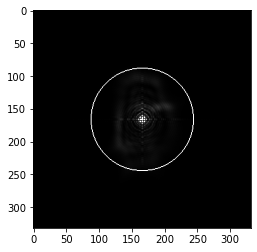

In [265]:
plt.imshow(eeimage,cmap='gray',vmin=0,vmax=50)

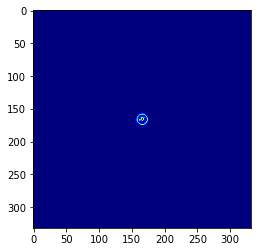

In [266]:
plt.imshow(eeimage2,cmap='jet',vmin=0,vmax=100)

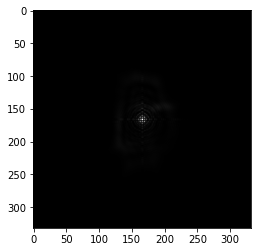

In [278]:
plt.imshow(norm(psfs[211]),cmap='gray',vmin=0,vmax=0.5)

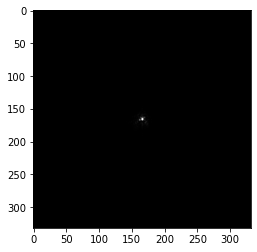

In [279]:
plt.imshow(norm(psfs[40]),cmap='gray',vmin=0,vmax=0.5)

Work out what unit this actually is - we could ask the aotools guys?

ERICA images

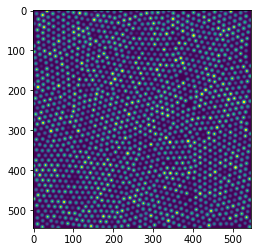

In [89]:
plt.imshow(imarray[4])

load convarray

In [90]:
test=numpy.load('eccentricity3_convolutions.npy')

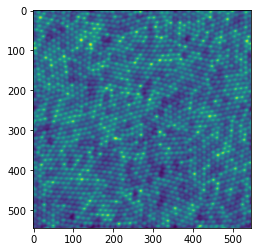

In [91]:
plt.imshow(test[0])

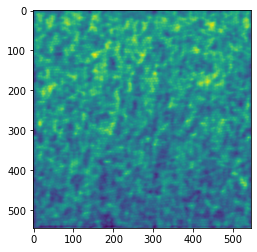

In [98]:
test2=numpy.load('eccentricity0_convolutions.npy')
plt.imshow(test2[0])

In [99]:
convarray0=numpy.load('eccentricity0_convolutions.npy')
convarray1=numpy.load('eccentricity1_convolutions.npy')
convarray2=numpy.load('eccentricity2_convolutions.npy')
convarray3=numpy.load('eccentricity3_convolutions.npy')
convarray4=numpy.load('eccentricity4_convolutions.npy')


In [50]:
print(convarray1.max())
print(convarray1.min())

7.311354279890801e-07
8.396816579829024e-08


In [169]:
convarray0=(convarray0-convarray0.min())/(convarray0.max()-convarray0.min())
convarray1=(convarray1-convarray1.min())/(convarray1.max()-convarray1.min())
convarray2=(convarray2-convarray2.min())/(convarray2.max()-convarray2.min())
convarray3=(convarray3-convarray3.min())/(convarray3.max()-convarray3.min())
convarray4=(convarray4-convarray4.min())/(convarray4.max()-convarray4.min())

In [170]:
def sqlaplace(imagedata): #this is the sharpness metric code
    
    arrl=numpy.gradient(imagedata)
    laplace = ((numpy.gradient(arrl[0])[0])+(numpy.gradient(arrl[1])[1]))**2
    S=numpy.sum(laplace)
    
    return S,laplace

def riemann(imagedata):
    arr=1+(numpy.gradient(imagedata)[0])**2+((numpy.gradient(imagedata)[1])**2-(numpy.gradient(imagedata)[0])**2)*(numpy.gradient(imagedata)[1])**2
    S=(1/(imagedata.shape[0]*imagedata.shape[1]))*numpy.nansum(abs(arr))
    return S,arr


In [171]:
print(convarray1.shape)

(250, 545, 545)


In [172]:
sd0=numpy.zeros((convarray0.shape[0]))
sql0=numpy.zeros((convarray0.shape[0]))
rie0=numpy.zeros((convarray0.shape[0]))

for c in range(convarray0.shape[0]):

    sd0[c]=numpy.std(convarray0[c])
    sql0[c]=sqlaplace(convarray0[c])[0]
    rie0[c]=riemann(convarray0[c])[0]

In [173]:
sd1=numpy.zeros((convarray1.shape[0]))
sql1=numpy.zeros((convarray1.shape[0]))
rie1=numpy.zeros((convarray1.shape[0]))

for c in range(convarray1.shape[0]):

    sd1[c]=numpy.std(convarray1[c])
    sql1[c]=sqlaplace(convarray1[c])[0]
    rie1[c]=riemann(convarray1[c])[0]

In [174]:
sd2=numpy.zeros((convarray2.shape[0]))
sql2=numpy.zeros((convarray2.shape[0]))
rie2=numpy.zeros((convarray2.shape[0]))

for c in range(convarray2.shape[0]):

    sd2[c]=numpy.std(convarray2[c])
    sql2[c]=sqlaplace(convarray2[c])[0]
    rie2[c]=riemann(convarray2[c])[0]

In [175]:
sd3=numpy.zeros((convarray3.shape[0]))
sql3=numpy.zeros((convarray3.shape[0]))
rie3=numpy.zeros((convarray3.shape[0]))

for c in range(convarray3.shape[0]):

    sd3[c]=numpy.std(convarray3[c])
    sql3[c]=sqlaplace(convarray3[c])[0]
    rie3[c]=riemann(convarray3[c])[0]

In [176]:
sd4=numpy.zeros((convarray4.shape[0]))
sql4=numpy.zeros((convarray4.shape[0]))
rie4=numpy.zeros((convarray4.shape[0]))

for c in range(convarray4.shape[0]):

    sd4[c]=numpy.std(convarray4[c])
    sql4[c]=sqlaplace(convarray4[c])[0]
    rie4[c]=riemann(convarray4[c])[0]

In [186]:
def norm(im):
    normim=(im-im.min())/(im.max()-im.min())
    return normim

    

In [177]:
encircledenergies=numpy.asarray(eedata)
print(encircledenergies.shape)
print(sd1.shape)
print(sql1.shape)
print(rie1.shape)

(250,)
(250,)
(250,)
(250,)


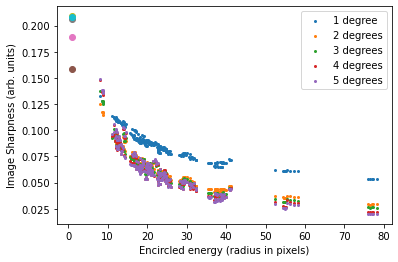

In [187]:
plt.scatter(eedata,sd0,s=4,label='1 degree')
plt.scatter(eedata,sd1,s=4,label='2 degrees')
plt.scatter(eedata,sd2,s=4,label='3 degrees')
plt.scatter(eedata,sd3,s=4,label='4 degrees')
plt.scatter(eedata,sd4,s=4,label='5 degrees')

plt.xlabel('Encircled energy (radius in pixels)')
plt.ylabel('Image Sharpness (arb. units)')

plt.scatter(1,numpy.std(norm(imarray[0])))
plt.scatter(1,numpy.std(norm(imarray[1])))
plt.scatter(1,numpy.std(norm(imarray[2])))
plt.scatter(1,numpy.std(norm(imarray[3])))
plt.scatter(1,numpy.std(norm(imarray[4])))

plt.legend()

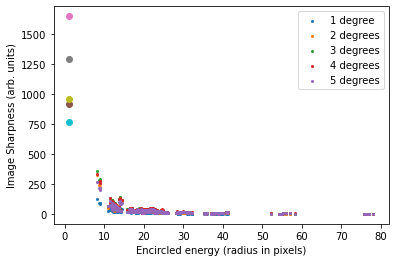

In [188]:
plt.scatter(eedata,sql0,s=4,label='1 degree')
plt.scatter(eedata,sql1,s=4,label='2 degrees')
plt.scatter(eedata,sql2,s=4,label='3 degrees')
plt.scatter(eedata,sql3,s=4,label='4 degrees')
plt.scatter(eedata,sql4,s=4,label='5 degrees')

plt.xlabel('Encircled energy (radius in pixels)')
plt.ylabel('Image Sharpness (arb. units)')

plt.scatter(1,sqlaplace(norm(imarray[0]))[0])
plt.scatter(1,sqlaplace(norm(imarray[1]))[0])
plt.scatter(1,sqlaplace(norm(imarray[2]))[0])
plt.scatter(1,sqlaplace(norm(imarray[3]))[0])
plt.scatter(1,sqlaplace(norm(imarray[4]))[0])

plt.legend()

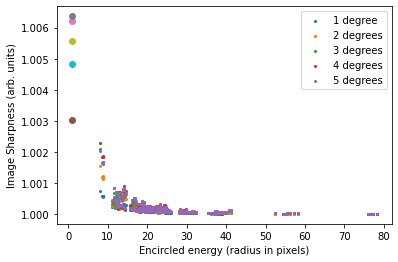

In [189]:
plt.scatter(eedata,rie0,s=4,label='1 degree')
plt.scatter(eedata,rie1,s=4,label='2 degrees')
plt.scatter(eedata,rie2,s=4,label='3 degrees')
plt.scatter(eedata,rie3,s=4,label='4 degrees')
plt.scatter(eedata,rie4,s=4,label='5 degrees')

plt.scatter(1,riemann(norm(imarray[0]))[0])
plt.scatter(1,riemann(norm(imarray[1]))[0])
plt.scatter(1,riemann(norm(imarray[2]))[0])
plt.scatter(1,riemann(norm(imarray[3]))[0])
plt.scatter(1,riemann(norm(imarray[4]))[0])

plt.xlabel('Encircled energy (radius in pixels)')
plt.ylabel('Image Sharpness (arb. units)')

plt.legend()

now the other plots

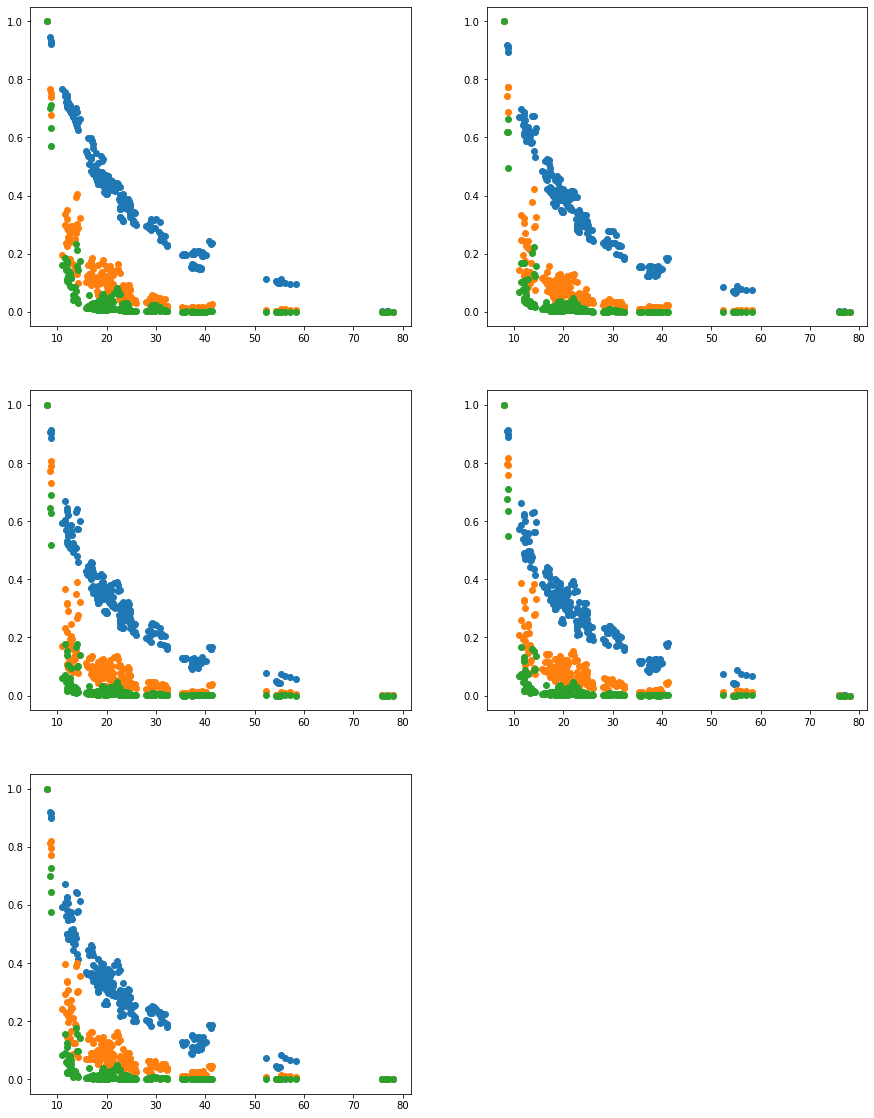

In [137]:
fig2 = plt.figure(2,figsize=(15,20))

ax1=fig2.add_subplot(3,2,1)
ax2=fig2.add_subplot(3,2,2)
ax3=fig2.add_subplot(3,2,3)
ax4=fig2.add_subplot(3,2,4)
ax5=fig2.add_subplot(3,2,5)

sd1norm=(sd1-sd1.min())/(sd1.max()-sd1.min())
sql1norm=(sql1-sql1.min())/(sql1.max()-sql1.min())
rie1norm=(rie1-rie1.min())/(rie1.max()-rie1.min())

sd2norm=(sd2-sd2.min())/(sd2.max()-sd2.min())
sql2norm=(sql2-sql2.min())/(sql2.max()-sql2.min())
rie2norm=(rie2-rie2.min())/(rie2.max()-rie2.min())

sd3norm=(sd3-sd3.min())/(sd3.max()-sd3.min())
sql3norm=(sql3-sql3.min())/(sql3.max()-sql3.min())
rie3norm=(rie3-rie3.min())/(rie3.max()-rie3.min())

sd4norm=(sd4-sd4.min())/(sd4.max()-sd4.min())
sql4norm=(sql4-sql4.min())/(sql4.max()-sql4.min())
rie4norm=(rie4-rie4.min())/(rie4.max()-rie4.min())

sd0norm=(sd0-sd0.min())/(sd0.max()-sd0.min())
sql0norm=(sql0-sql0.min())/(sql0.max()-sql0.min())
rie0norm=(rie0-rie0.min())/(rie0.max()-rie0.min())


ax1.scatter(eedata,sd0norm)
ax1.scatter(eedata,sql0norm)
ax1.scatter(eedata,rie0norm) 
    
ax2.scatter(eedata,sd1norm)
ax2.scatter(eedata,sql1norm)
ax2.scatter(eedata,rie1norm)  

ax3.scatter(eedata,sd2norm)
ax3.scatter(eedata,sql2norm)
ax3.scatter(eedata,rie2norm) 

ax4.scatter(eedata,sd3norm)
ax4.scatter(eedata,sql3norm)
ax4.scatter(eedata,rie3norm) 

ax5.scatter(eedata,sd4norm)
ax5.scatter(eedata,sql4norm)
ax5.scatter(eedata,rie4norm)  

plt.savefig('Figure2.png')

# ACTUAL IMAGES

import the images

In [290]:
folder = 'F:/Parkinsons Experiment/AOSLO_montages/NCLC0012/processed/Montage'

realimages=fits.getdata(os.path.join(folder,'data_stream_039_24_06_24-10_57_10_overallTrial_00039_EXTRACTED.fits'))

savefolder='F:/Parkinsons Experiment/AOSLO_montages/NCLC0012/anim'
print(realimages.shape)

(1, 59, 526, 361, 2)


Calculate the sharpness metrics

In [291]:
sd=[]
sql=[]
rie=[]

for i in range(realimages.shape[1]):
    ima=realimages[0,i,:,:,0]
    imnorm=(ima-ima.min())/(ima.max()-ima.min())
    sd.append(numpy.std(imnorm))
    sql.append(sqlaplace(imnorm)[0])
    rie.append(riemann(imnorm)[0])
    
print(len(sd))    

59


Create time spacings

In [292]:
tspacing=1./30.
print(tspacing)
print(realimages.shape[1])
Time=numpy.arange(0,realimages.shape[1]*tspacing,tspacing,dtype='float')
print(len(Time))

0.03333333333333333
59
59


Plot

Text(0, 0.5, 'Sharpness (arb units)')

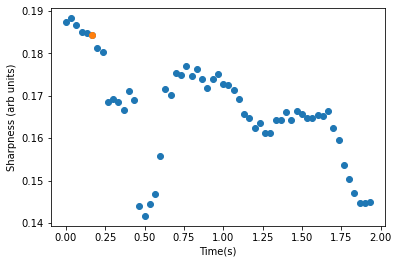

In [293]:
plt.scatter(Time,sd)
plt.scatter(Time[5],sd[5])

plt.xlabel('Time(s)')
plt.ylabel('Sharpness (arb units)')

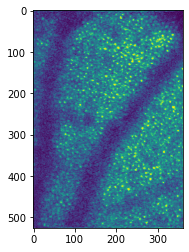

In [294]:
plt.imshow(realimages[0,5,:,:,0])

Text(0, 0.5, 'Sharpness (arb units)')

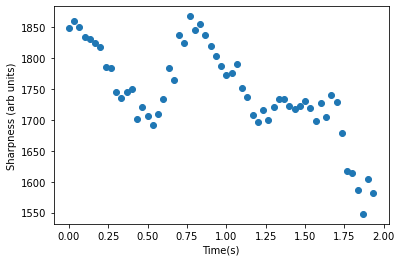

In [295]:
plt.scatter(Time,sql)
plt.xlabel('Time(s)')
plt.ylabel('Sharpness (arb units)')

Text(0, 0.5, 'Sharpness (arb units)')

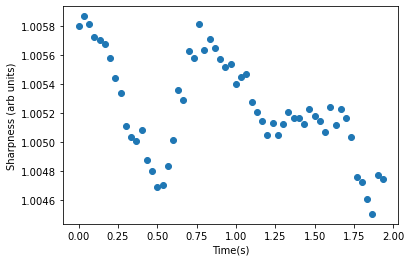

In [296]:
plt.scatter(Time,rie)
plt.xlabel('Time(s)')
plt.ylabel('Sharpness (arb units)')

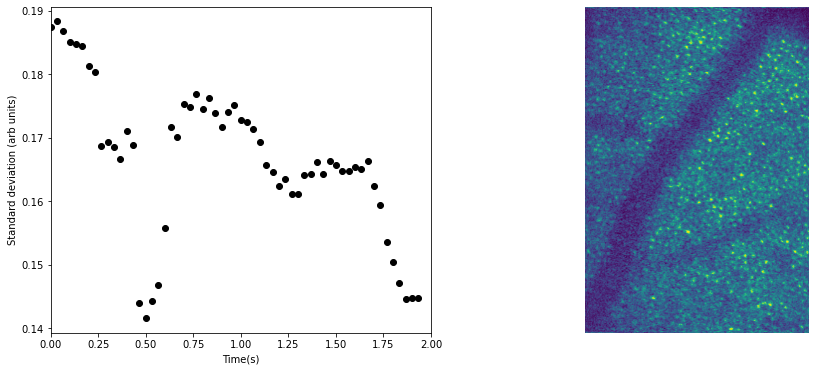

In [300]:
figure=plt.figure(1, figsize=(15,6))
ax1=figure.add_subplot(1,2,1)
ax2=figure.add_subplot(1,2,2)
for n in range(0,len(Time)):
    ax1.scatter(Time[n],sd[n],c='black')
    ax1.set_xlabel('Time(s)')
    ax1.set_ylabel('Standard deviation (arb units)')
    ax1.set_xlim(0,2)
    ax2.imshow(realimages[0,n,:,:,0])
    ax2.set_axis_off()
    plt.savefig(os.path.join(savefolder,'sd_%03i.png'%n))
    
    
    
    

turn these into an animation?  could be a bit shonky...

Note that these are close to the ERICA results for a perfect image - so this was a good participant!

Do you want to do one for a poor quality participant too?

In [ ]:
You now need to use the code you've made to use metrics to calculate 

In [ ]:
choose a point to remove all the poor images

In [ ]:
calculate average

In [ ]:
use software for this?

Can we show perhaps that some features are visible using different metrics that aren't visible when we use others?  Might be too subtle.

In [ ]:
Add functionality in code to save all the average images to a folder

In [ ]:
name the folder after the metric used

In [ ]:
do the comparison